In [44]:
import psycopg2
from dotenv import load_dotenv
import os 

load_dotenv()
url = os.getenv("DATABASE_URL")

In [45]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

OperationalError: connection to server at "interchange.proxy.rlwy.net" (66.33.22.238), port 36635 failed: server closed the connection unexpectedly
	This probably means the server terminated abnormally
	before or while processing the request.


In [ ]:
cur.execute(
    """
    SELECT DISTINCT ticker
    FROM orderbooks
    """
)
tickers = [row[0] for row in cur.fetchall()]
print(tickers)

In [46]:
import pandas as pd

ticker = "SR310CD6B"
columns = ["id", "ticker", "timestamp", "bids", "asks"] 

query = f"""
SELECT {', '.join(columns)}
FROM orderbooks
WHERE ticker = '{ticker}'
"""

option_df = pd.read_sql_query(query, conn)

option_df['timestamp'] = pd.to_datetime(option_df['timestamp'])
option_df.set_index('timestamp', inplace=True)

option_df['best_bid'] = option_df['bids'].apply(lambda bids: bids[0]['price'] if bids else None)
option_df['best_ask'] = option_df['asks'].apply(lambda asks: asks[0]['price'] if asks else None)
option_df['mid_price'] = option_df['best_bid'] + (option_df['best_ask'] - option_df['best_bid'])/2
option_df['spread'] = option_df['best_ask'] - option_df['best_bid']

option_df.drop(columns=['bids', 'asks', 'id'], inplace=True)
option_df = option_df[~option_df.index.duplicated(keep='first')]
option_df.drop_duplicates(inplace=True)
option_df.head()

C:\Users\bakae\AppData\Local\Temp\ipykernel_2432\1019981541.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  option_df = pd.read_sql_query(query, conn)


,ticker,best_bid,best_ask,mid_price,spread
timestamp,,,,,
2026-03-26 15:50:00+00:00,SR310CD6B,8.5,9.62,9.060,1.12
2026-03-26 15:53:22+00:00,SR310CD6B,8.5,NaN,NaN,NaN
2026-03-26 15:53:34+00:00,SR310CD6B,8.5,10.69,9.595,2.19
2026-03-26 19:39:32+00:00,SR310CD6B,8.5,9.11,8.805,0.61
2026-03-26 19:39:34+00:00,SR310CD6B,8.5,9.32,8.910,0.82


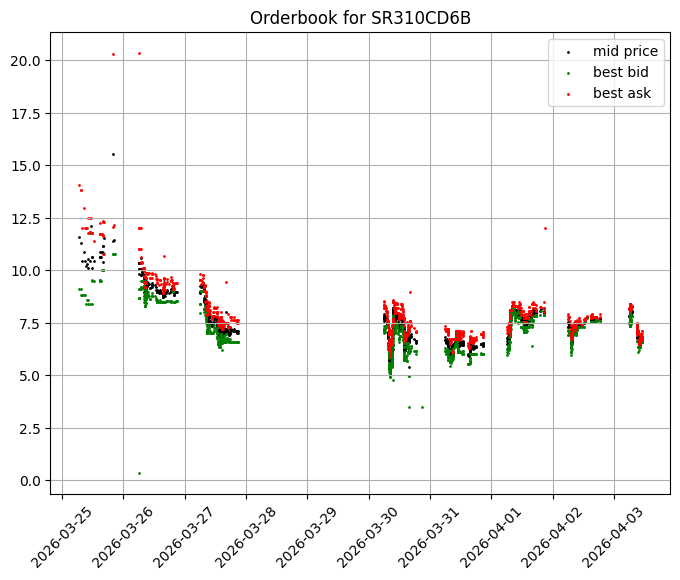

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(option_df.index, option_df['mid_price'], color="black", s=1, label="mid price")
plt.scatter(option_df.index, option_df['best_bid'], color="green", s=1, label="best bid")
plt.scatter(option_df.index, option_df['best_ask'], color="red", s=1, label="best ask")
plt.title(f"Orderbook for {ticker}")
plt.tick_params(axis='x', rotation=45)
plt.legend()
plt.grid()
plt.show()

In [48]:
columns = ["id", "ticker", "timestamp", "side", "volume", "price", "quantity"] 

query = f"""
SELECT {', '.join(columns)}
FROM orders
WHERE ticker = '{ticker}'
"""

orders_df = pd.read_sql_query(query, conn)
orders_df.head()

C:\Users\bakae\AppData\Local\Temp\ipykernel_2432\3326554322.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_df = pd.read_sql_query(query, conn)


,id,ticker,timestamp,side,volume,price,quantity
0,313,SR310CD6B,2026-03-25 07:31:58+00:00,BUY,97,13,7
1,334,SR310CD6B,2026-03-25 08:30:07+00:00,BUY,84,12,7
2,335,SR310CD6B,2026-03-25 08:33:59+00:00,BUY,1003,12,83
3,364,SR310CD6B,2026-03-25 10:10:14+00:00,BUY,12,12,1
4,372,SR310CD6B,2026-03-25 10:47:47+00:00,BUY,118,11,10


Text(0.5, 0, 'date')

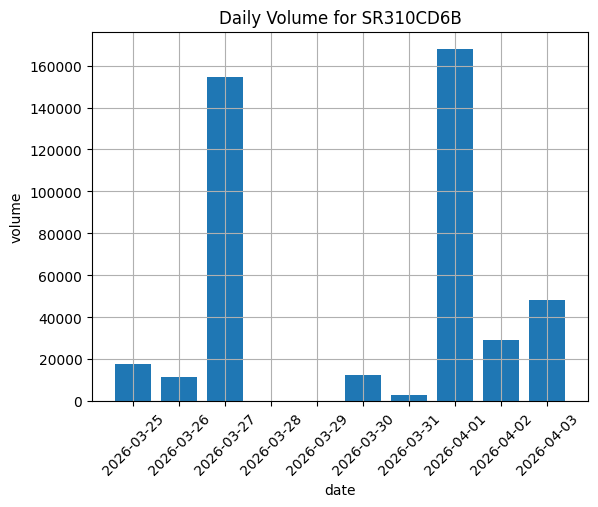

In [53]:
orders_df["timestamp"] = pd.to_datetime(orders_df["timestamp"])
orders_df["date"] = orders_df["timestamp"].dt.date

daily_volume = orders_df.groupby("date")["volume"].sum()

plt.bar(daily_volume.index, daily_volume.values)
plt.tick_params(axis='x', rotation=45)
plt.grid()
plt.title(f"Daily Volume for {ticker}")
plt.ylabel("volume")
plt.xlabel("date")